In [1]:
import os
import joblib
import tensorflow as tf
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ecdf
from itertools import permutations, combinations
from matplotlib import rcParams, cycler
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc11 import *

In [2]:
## Try running the optimizer with no identifiability
## See what the order permutations are for the top N exploration samples
## Reoptimize on just that discrete set of permutations
## See which one wins out

In [3]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [4]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01, 0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [5]:
# Initialize X and Y
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [6]:
data = {
    'free': joblib.load(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'permutation_test_free.pkl')),
    'random': joblib.load(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'permutation_test_random.pkl')),
    'multi_sample': joblib.load(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'permutation_test_top120_multi_sample.pkl')),
    'final_opt': joblib.load(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'sgcc_mop_4_18_26.pkl'))
}

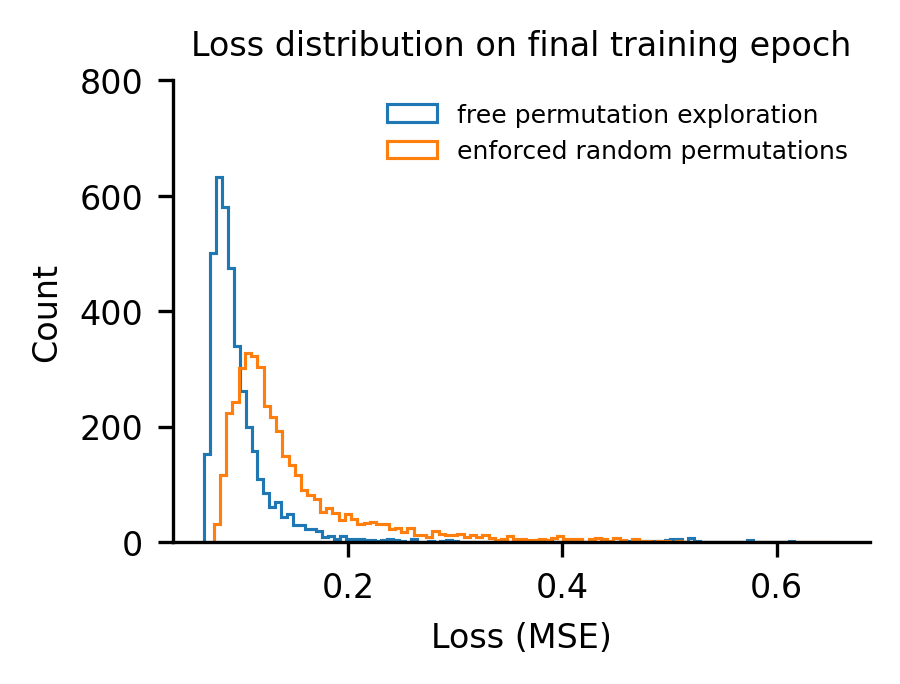

In [7]:
fig, ax = plt.subplots(figsize = (3,2))
ax.hist(
    data['free']['loss_decay'][-1], 
    bins = 100, 
    histtype='step', 
    label = 'free permutation exploration',
    linewidth = 0.75
)
ax.hist(
    data['random']['loss_decay'][-1], 
    bins = 100, 
    histtype='step', 
    label = 'enforced random permutations',
    linewidth = 0.75
)
# ax.hist(
#     data['multi_sample']['loss_decay'][-1], 
#     bins = 100, 
#     histtype='step', 
#     label = 'enforced random permutations',
#     linewidth = 0.75
# )
ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Count", fontsize = fontsize)
ax.set_xlabel("Loss (MSE)", fontsize = fontsize)
#ax.set_xticks(np.arange(0,0.35,0.05))
ax.set_ylim(0,800)
ax.set_title("Loss distribution on final training epoch", fontsize = fontsize)
ax.legend(fontsize = 6, frameon = False)

figname = 'loss_dist_free_vs_random_permutations.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

In [8]:
from scipy.stats import ttest_ind, ks_2samp, ttest_rel, mannwhitneyu

In [9]:
ttest_ind(
    data['free']['loss_decay'][-1],
    data['random']['loss_decay'][-1],
    alternative='less'
)

TtestResult(statistic=-30.38923745676009, pvalue=2.300660853811948e-192, df=7998.0)

In [10]:
ttest_rel(
    data['free']['loss_decay'][-1],
    data['random']['loss_decay'][-1],
    alternative='less'
)

TtestResult(statistic=-30.2668171466039, pvalue=1.1235959908086739e-181, df=3999)

In [11]:
ks_2samp(
    data['free']['loss_decay'][-1],
    data['random']['loss_decay'][-1],
    'two-sided'
)

KstestResult(statistic=0.5105, pvalue=0.0, statistic_location=0.1006, statistic_sign=1)

In [12]:
## Credit goes to skynaut (2015) on Stackoverflow: https://stackoverflow.com/questions/21532471/how-to-calculate-cohens-d-in-python
def cohensd(x,y):
    if len(x) == len(y):
        return (np.mean(x) - np.mean(y)) / np.sqrt((np.std(x, ddof=1) ** 2 + np.std(y, ddof=1) ** 2) / 2.0)
    else:
        nx = len(x)
        ny = len(y)
        dof = nx + ny - 2
        return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)

In [13]:
cohensd(
    data['free']['loss_decay'][-1],
    data['random']['loss_decay'][-1]
)

-0.679499984127873

In [14]:
def calculate_monotonicity(params, sample_indices, v1_unit, split = True):
    gather_list = []
    for i in sample_indices:
        d = pd.DataFrame(
                params[i,v1_unit,:,:,0,0]
            ).corr(method='spearman').values
        if split:
            for i in range(7):
                for z in range(i,7):
                    try:
                        d[i,z+1] = np.nan
                    except IndexError:
                        pass
        gather_list.append(d)
    return np.array(gather_list)

In [15]:
lsi_rand = np.argsort(data['random']['loss_decay'][-1]) # loss sorting index

In [16]:
random_run = [
    calculate_monotonicity(data['random']['param_history']['dLGN_params'][:,-1], lsi_rand, 0),
    calculate_monotonicity(data['random']['param_history']['dLGN_params'][:,-1], lsi_rand, 1)
]

Text(0.5, 1.0, 'dLGN inputs into V1_2')

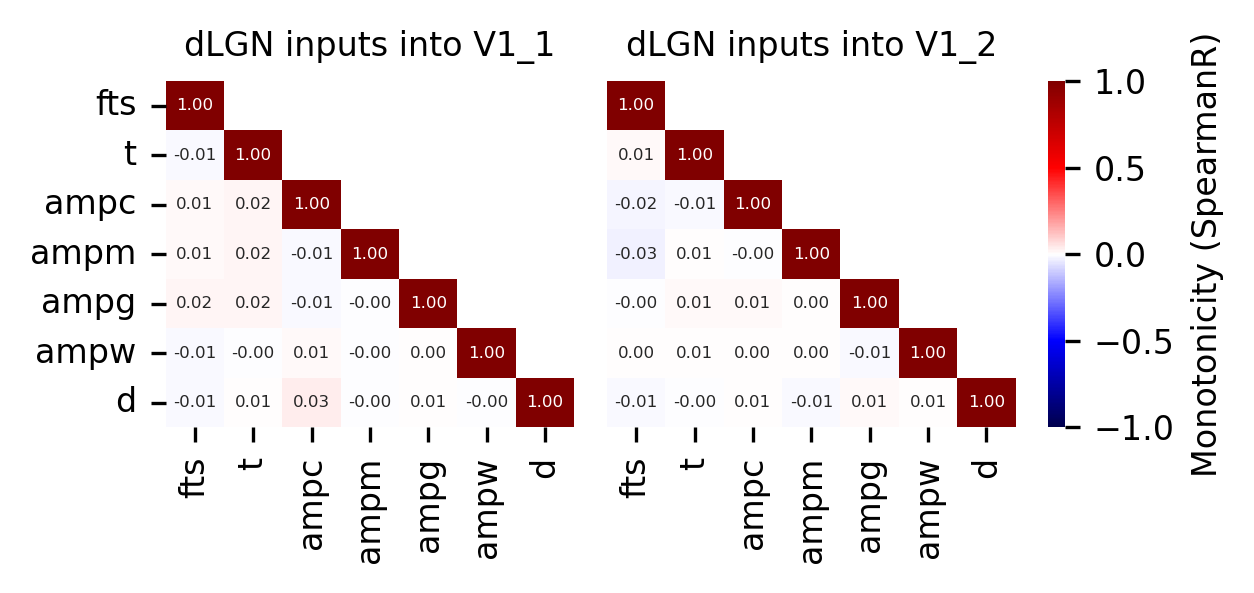

In [17]:
fig = plt.figure(figsize = (4.5, 1.5))
grid = plt.GridSpec(9,22, wspace=2, hspace=1)
ax = [
    fig.add_subplot(grid[:9,:9]),
    fig.add_subplot(grid[:9,9:18]),
    fig.add_subplot(grid[:,18:19]),
    
]

for i, val in enumerate(random_run):
    sns.heatmap(
        val[lsi_rand[:]].mean(0), 
        ax = ax[i], 
        vmin = -1, vmax = 1, 
        cbar_ax=ax[2], 
        cmap = 'seismic', 
        cbar_kws={'label': 'Monotonicity (SpearmanR)'}, 
        annot=True, annot_kws={'size': 4}, fmt = '.2f'
    )
    ax[i].tick_params(labelsize = 8)
    if i == 0:
        ax[i].set_yticks(np.arange(7)+0.5)
        ax[i].set_yticklabels(list(param_bounds.keys())[:-2], fontsize = 8, rotation = 0)
    else:
        ax[i].set_yticks([])

    ax[i].set_xticks(np.arange(7)+0.5)
    ax[i].set_xticklabels(list(param_bounds.keys())[:-2], fontsize = 8, rotation = 90)
    ax[-1].figure.axes[-1].yaxis.label.set_size(8)
    ax[-1].figure.axes[-1].tick_params(labelsize = 8)

ax[0].set_title("dLGN inputs into V1_1", fontsize = 8)
ax[1].set_title("dLGN inputs into V1_2", fontsize = 8)

# figname = 'random_permutation_SAM.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [18]:
lsi_free = np.argsort(data['free']['loss_decay'][-1]) # loss sorting index
free_run = [
    calculate_monotonicity(data['free']['param_history']['dLGN_params'][:,-1], lsi_free, 0),
    calculate_monotonicity(data['free']['param_history']['dLGN_params'][:,-1], lsi_free, 1)
]

Text(0.5, 1.0, 'dLGN inputs into V1_2')

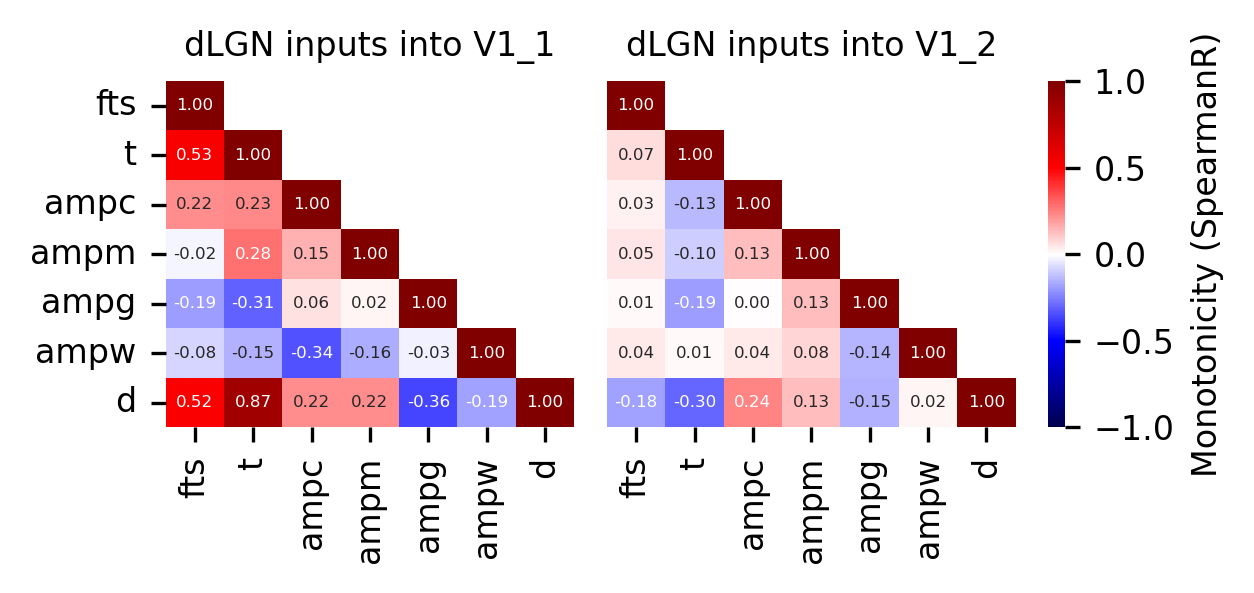

In [19]:
fig = plt.figure(figsize = (4.5, 1.5))
grid = plt.GridSpec(9,22, wspace=2, hspace=1)
ax = [
    fig.add_subplot(grid[:9,:9]),
    fig.add_subplot(grid[:9,9:18]),
    fig.add_subplot(grid[:,18:19]),
    
]

for i, val in enumerate(free_run):
    sns.heatmap(
        val[lsi_free[:]].mean(0), 
        ax = ax[i], 
        vmin = -1, vmax = 1, 
        cbar_ax=ax[2], 
        cmap = 'seismic', 
        cbar_kws={'label': 'Monotonicity (SpearmanR)'}, 
        annot=True, annot_kws={'size': 4}, fmt = '.2f'
    )
    ax[i].tick_params(labelsize = 8)
    if i == 0:
        ax[i].set_yticks(np.arange(7)+0.5)
        ax[i].set_yticklabels(list(param_bounds.keys())[:-2], fontsize = 8, rotation = 0)
    else:
        ax[i].set_yticks([])

    ax[i].set_xticks(np.arange(7)+0.5)
    ax[i].set_xticklabels(list(param_bounds.keys())[:-2], fontsize = 8, rotation = 90)
    ax[-1].figure.axes[-1].yaxis.label.set_size(8)
    ax[-1].figure.axes[-1].tick_params(labelsize = 8)

ax[0].set_title("dLGN inputs into V1_1", fontsize = 8)
ax[1].set_title("dLGN inputs into V1_2", fontsize = 8)

# figname = 'free_permutation_SAM.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [20]:
lsi_multi_sample = np.argsort(data['multi_sample']['loss_decay'][-1]) # loss sorting index
multi_sample_run = [
    calculate_monotonicity(data['multi_sample']['params']['dLGN_params'], lsi_multi_sample, 0),
    calculate_monotonicity(data['multi_sample']['params']['dLGN_params'], lsi_multi_sample, 1)
]

Text(0.5, 1.0, 'dLGN inputs into V1_2')

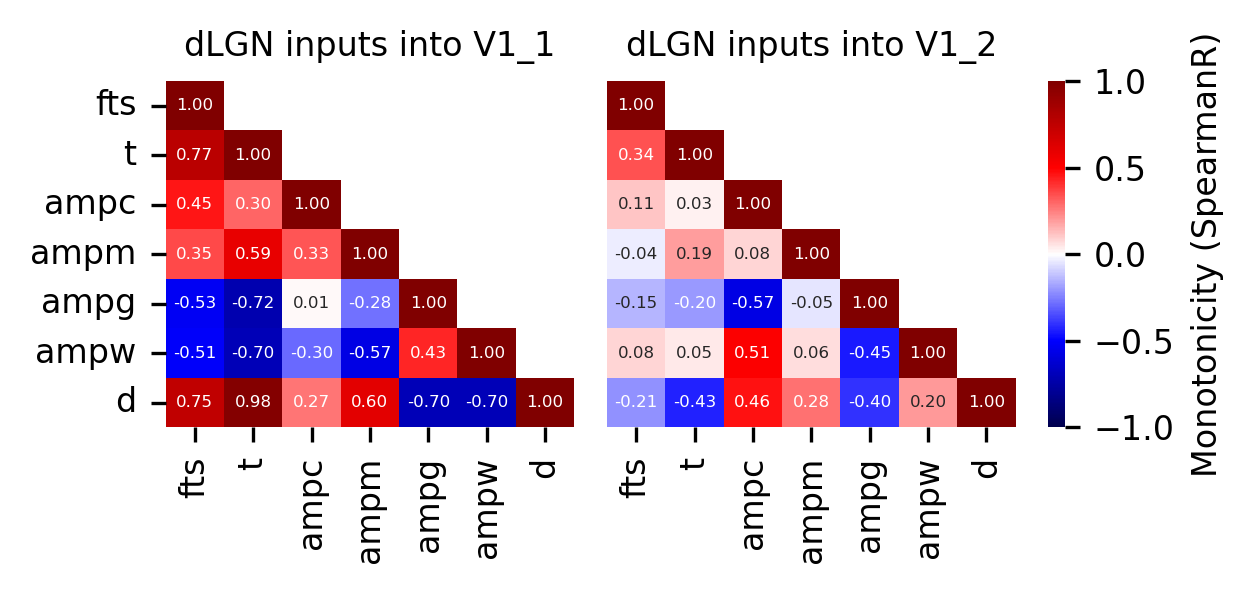

In [21]:
fig = plt.figure(figsize = (4.5, 1.5))
grid = plt.GridSpec(9,22, wspace=2, hspace=1)
ax = [
    fig.add_subplot(grid[:9,:9]),
    fig.add_subplot(grid[:9,9:18]),
    fig.add_subplot(grid[:,18:19]),
    
]

for i, val in enumerate(multi_sample_run):
    sns.heatmap(
        val[lsi_multi_sample[:]].mean(0), 
        ax = ax[i], 
        vmin = -1, vmax = 1, 
        cbar_ax=ax[2], 
        cmap = 'seismic', 
        cbar_kws={'label': 'Monotonicity (SpearmanR)'}, 
        annot=True, annot_kws={'size': 4}, fmt = '.2f'
    )
    ax[i].tick_params(labelsize = 8)
    if i == 0:
        ax[i].set_yticks(np.arange(7)+0.5)
        ax[i].set_yticklabels(list(param_bounds.keys())[:-2], fontsize = 8, rotation = 0)
    else:
        ax[i].set_yticks([])

    ax[i].set_xticks(np.arange(7)+0.5)
    ax[i].set_xticklabels(list(param_bounds.keys())[:-2], fontsize = 8, rotation = 90)
    ax[-1].figure.axes[-1].yaxis.label.set_size(8)
    ax[-1].figure.axes[-1].tick_params(labelsize = 8)

ax[0].set_title("dLGN inputs into V1_1", fontsize = 8)
ax[1].set_title("dLGN inputs into V1_2", fontsize = 8)

# figname = 'multisample_permutation_SAM.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [22]:
random_run = [
    calculate_monotonicity(data['random']['param_history']['dLGN_params'][:,-1], lsi_rand, 0, split=False),
    calculate_monotonicity(data['random']['param_history']['dLGN_params'][:,-1], lsi_rand, 1, split=False)
]

In [23]:
lsi_free = np.argsort(data['free']['loss_decay'][-1]) # loss sorting index
free_run = [
    calculate_monotonicity(data['free']['param_history']['dLGN_params'][:,-1], lsi_free, 0, split=False),
    calculate_monotonicity(data['free']['param_history']['dLGN_params'][:,-1], lsi_free, 1, split=False)
]

In [24]:
lsi_multi_sample = np.argsort(data['multi_sample']['loss_decay'][-1]) # loss sorting index
multi_sample_run = [
    calculate_monotonicity(data['multi_sample']['params']['dLGN_params'], lsi_multi_sample, 0, split=False),
    calculate_monotonicity(data['multi_sample']['params']['dLGN_params'], lsi_multi_sample, 1, split=False)
]

In [25]:
import statsmodels.api as sm
import statsmodels

In [26]:
cov_list = [random_run[0].mean(0), free_run[0].mean(0)]
nobs_list = [4000,4000]
statsmodels.stats.multivariate.test_cov_oneway(cov_list, nobs_list)

<class 'statsmodels.stats.base.HolderTuple'>
statistic = 200.45199751630315
pvalue = 0.0
statistic_base = 5617.836874576085
statistic_chi2 = 5612.656636147728
pvalue_chi2 = 0.0
df_chi2 = 28.0
distr_chi2 = 'chi2'
statistic_f = 200.45199751630315
pvalue_f = 0.0
df_f = (28.0, 222901211.7604359)
distr_f = 'F'
tuple = (200.45199751630315, 0.0)

In [27]:
cov_list = [random_run[0].mean(0), multi_sample_run[0].mean(0)]
nobs_list = [4000,12000]
statsmodels.stats.multivariate.test_cov_oneway(cov_list, nobs_list)

<class 'statsmodels.stats.base.HolderTuple'>
statistic = 1485.476228388522
pvalue = 0.0
statistic_base = 41621.05764120394
statistic_chi2 = 41593.340091191036
pvalue_chi2 = 0.0
df_chi2 = 28.0
distr_chi2 = 'chi2'
statistic_f = 1485.476228388522
pvalue_f = 0.0
df_f = (28.0, 204586674.2005418)
distr_f = 'F'
tuple = (1485.476228388522, 0.0)

In [28]:
cov_list = [free_run[0].mean(0), multi_sample_run[0].mean(0)]
nobs_list = [4000,12000]
statsmodels.stats.multivariate.test_cov_oneway(cov_list, nobs_list)

<class 'statsmodels.stats.base.HolderTuple'>
statistic = 542.0948976182922
pvalue = 0.0
statistic_base = 15188.774178668522
statistic_chi2 = 15178.659212067694
pvalue_chi2 = 0.0
df_chi2 = 28.0
distr_chi2 = 'chi2'
statistic_f = 542.0948976182922
pvalue_f = 0.0
df_f = (28.0, 204586674.2005418)
distr_f = 'F'
tuple = (542.0948976182922, 0.0)

In [29]:
cov_list = [random_run[1].mean(0), free_run[1].mean(0)]
nobs_list = [4000,4000]
statsmodels.stats.multivariate.test_cov_oneway(cov_list, nobs_list)

<class 'statsmodels.stats.base.HolderTuple'>
statistic = 28.700626247590737
pvalue = 3.7083633608373044e-151
statistic_base = 804.3593401658565
statistic_chi2 = 803.6176359730929
pvalue_chi2 = 3.705667815099052e-151
df_chi2 = 28.0
distr_chi2 = 'chi2'
statistic_f = 28.700626247590737
pvalue_f = 3.7083633608373044e-151
df_f = (28.0, 222901211.7604359)
distr_f = 'F'
tuple = (28.700626247590737, 3.7083633608373044e-151)

In [30]:
cov_list = [random_run[1].mean(0), multi_sample_run[1].mean(0)]
nobs_list = [4000,12000]
statsmodels.stats.multivariate.test_cov_oneway(cov_list, nobs_list)

<class 'statsmodels.stats.base.HolderTuple'>
statistic = 292.62091557840074
pvalue = 0.0
statistic_base = 8198.846781629585
statistic_chi2 = 8193.386758300121
pvalue_chi2 = 0.0
df_chi2 = 28.0
distr_chi2 = 'chi2'
statistic_f = 292.62091557840074
pvalue_f = 0.0
df_f = (28.0, 204586674.2005418)
distr_f = 'F'
tuple = (292.62091557840074, 0.0)

In [31]:
cov_list = [free_run[1].mean(0), multi_sample_run[1].mean(0)]
nobs_list = [4000,12000]
statsmodels.stats.multivariate.test_cov_oneway(cov_list, nobs_list)

<class 'statsmodels.stats.base.HolderTuple'>
statistic = 162.8606053727592
pvalue = 0.0
statistic_base = 4563.136396369246
statistic_chi2 = 4560.097574954078
pvalue_chi2 = 0.0
df_chi2 = 28.0
distr_chi2 = 'chi2'
statistic_f = 162.8606053727592
pvalue_f = 0.0
df_f = (28.0, 204586674.2005418)
distr_f = 'F'
tuple = (162.8606053727592, 0.0)

In [32]:
msl = data['multi_sample']['loss_decay'][-1].reshape(100,120)
msl_i1 = np.argsort(msl.mean(0))
msl_i2 = np.argsort(msl.mean(1))

Text(0, 0.5, 'Loss')

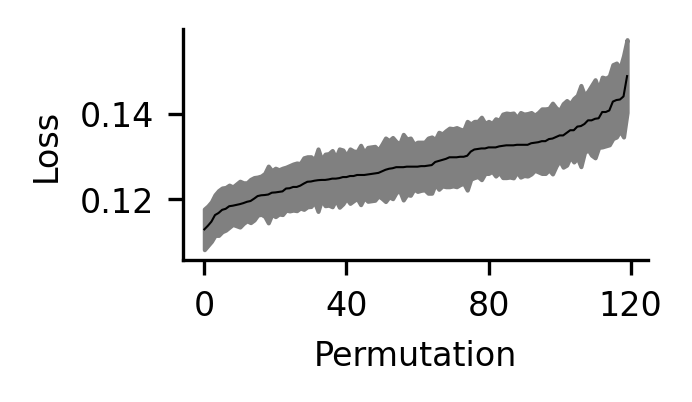

In [33]:
fig, ax = plt.subplots(figsize = (2,1))
ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.plot(msl[:,msl_i1].mean(0), color = 'black', linewidth = linewidth)
ax.fill_between(
    np.arange(len(msl[:,msl_i1].mean(0))),
    msl[:,msl_i1].mean(0) + msl[:,msl_i1].std(0)/np.sqrt(msl[:,msl_i1].shape[0]),
    msl[:,msl_i1].mean(0) - msl[:,msl_i1].std(0)/np.sqrt(msl[:,msl_i1].shape[0]),
    color = 'gray'
)
ax.set_xticks(np.arange(0,160,40))
ax.set_xlabel("Permutation", fontsize = 8)
ax.set_ylabel("Loss", fontsize = 8)

# figname = 'best_120_perm_loss.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [34]:
pvals = []
for i in msl_i1[:]:
    ref = msl[:,msl_i1[0]]
    comp = msl[:,i]
    pvals.append(ttest_rel(ref, comp, alternative='less')[1])
pvals = np.array(pvals)

In [35]:
pbetter = pvals[pvals>0.05].shape[0]/120

Text(0, 0.5, 'Pval')

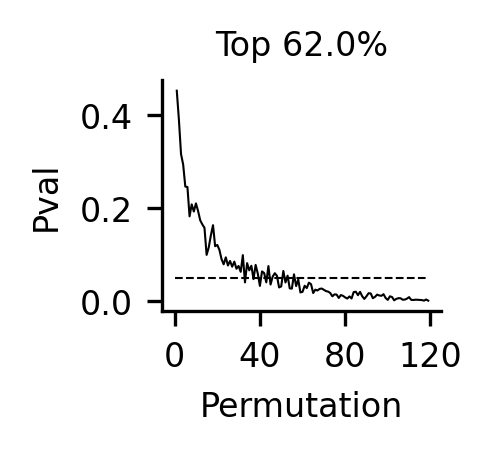

In [36]:
fig, ax = plt.subplots(figsize = (1.2,1))
ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.plot(pvals, linewidth = 0.5, color = 'black')
ax.plot(np.arange(120), [0.05]*120, '--', linewidth = 0.5, color = 'black')
ax.set_xticks(np.arange(0,160,40))
ax.set_title(f"Top {100-np.round(pbetter, 2)*100}%", fontsize = 8)
ax.set_xlabel("Permutation", fontsize = 8)
ax.set_ylabel("Pval", fontsize = 8)

# figname = 'best_120_perm_comparison.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [37]:
params = data['multi_sample']['params']['dLGN_params'].reshape(100,120,2,3,7)

In [38]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01,0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

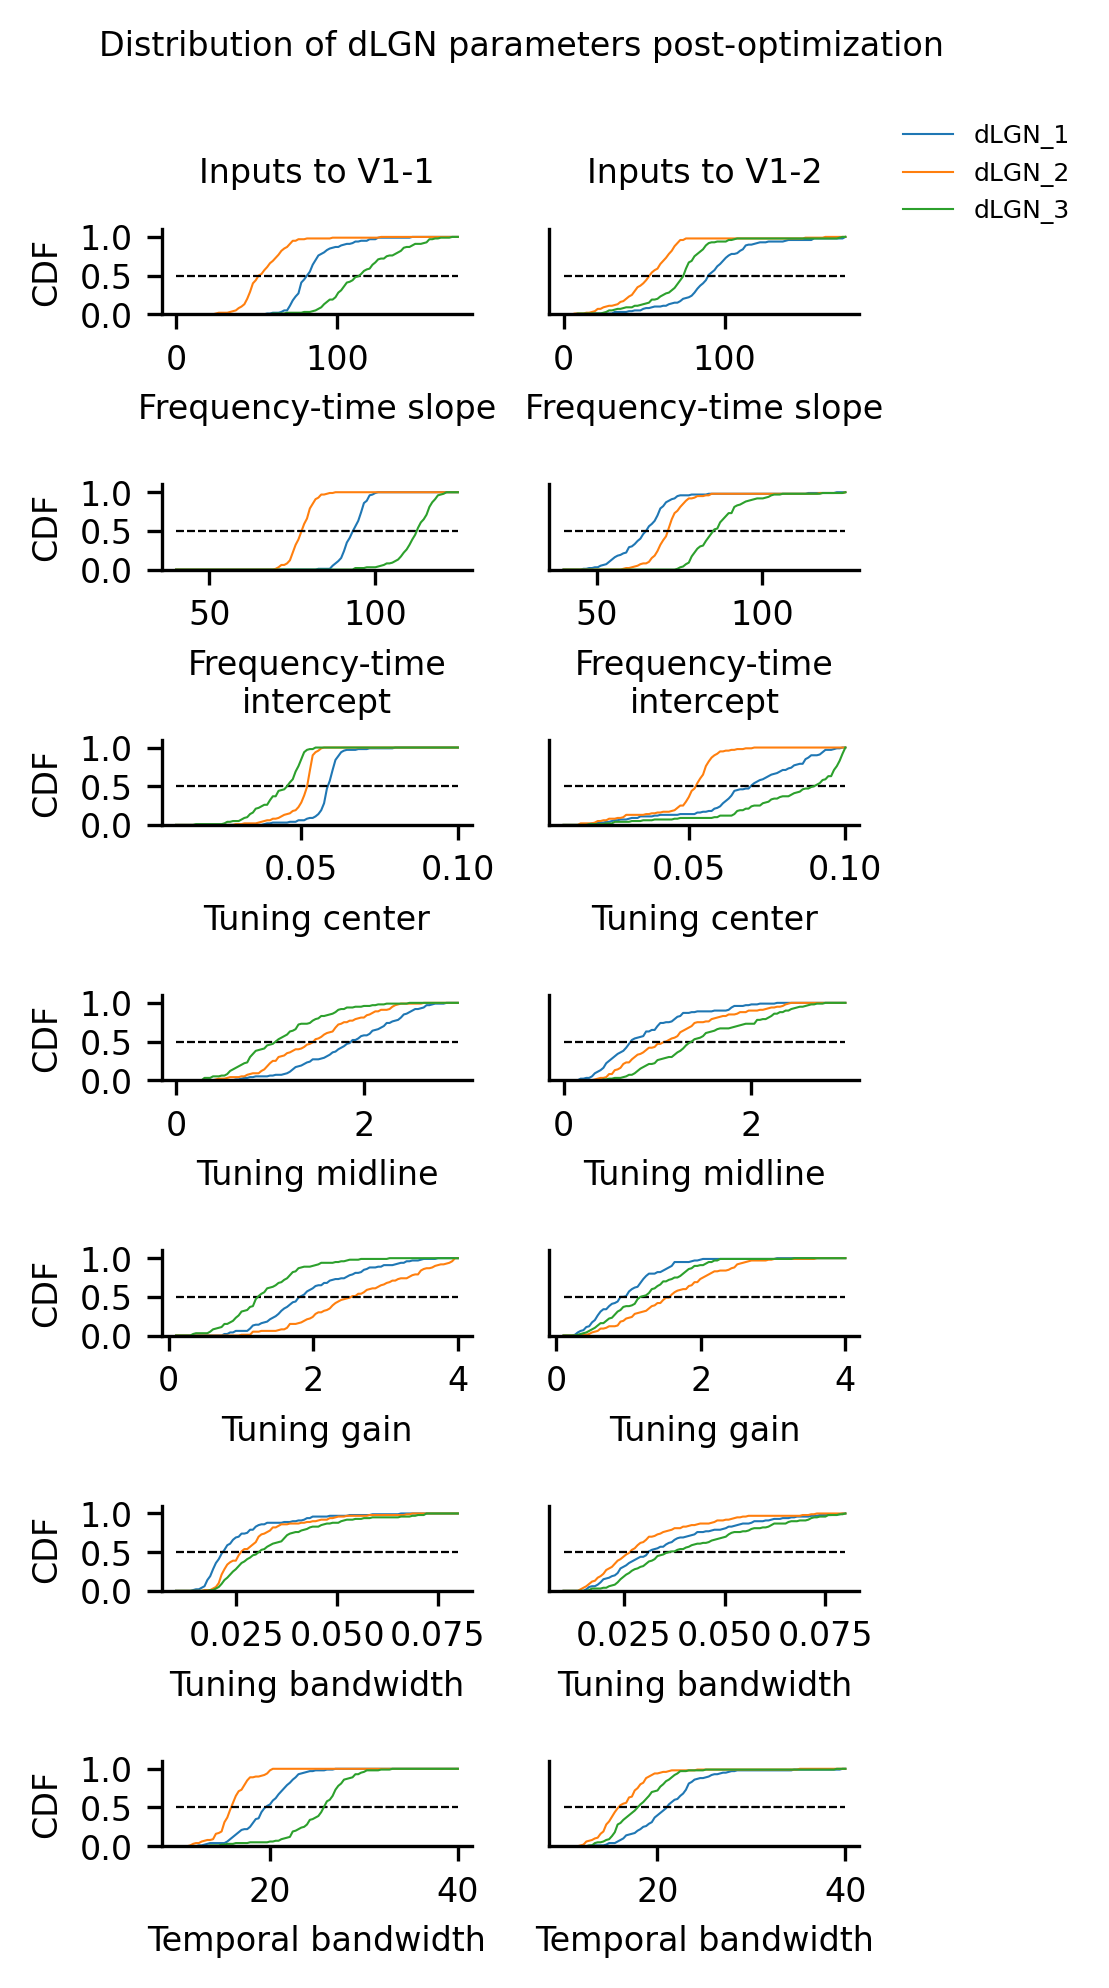

In [39]:
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            d = params[:,msl_i1[0],u,i,row]
            x = np.linspace(
                list(param_bounds.values())[:7][row][0],
                list(param_bounds.values())[:7][row][1], 
                100
            )
            kde = ecdf(d).cdf
            y = kde.evaluate(x)

            ymax.append(y.max())

            ax[row, u].plot(x, np.full(len(x), 0.5), '--', color = 'black', linewidth = linewidth)
            ax[row, u].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)

figname = '2d_model_dlgn_param_density_func_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [40]:
p_top = params[0,msl_i1[0]][None,:,:,:]
op_perm = np.argsort(np.argsort(p_top, axis=2), axis=2).transpose(0,3,1,2)

P = tf.one_hot(
    op_perm,
    3,
    axis=-1,
)
P = tf.transpose(P, (0,1,2,4,3))

P = tf.where(P == 1.0, 
                  tf.ones_like(P) * 10.0,   # large positive
                  tf.ones_like(P) * -10.0)  # large negative

P = np.squeeze(np.tile(P, [4000, 1, 1, 1, 1, 1]))

In [41]:
# joblib.dump(P,os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'best_permutation.pkl'))

In [42]:
data['final_opt']['param_history']['dLGN_params'][:,-1].shape

(4000, 2, 3, 7, 1, 1)

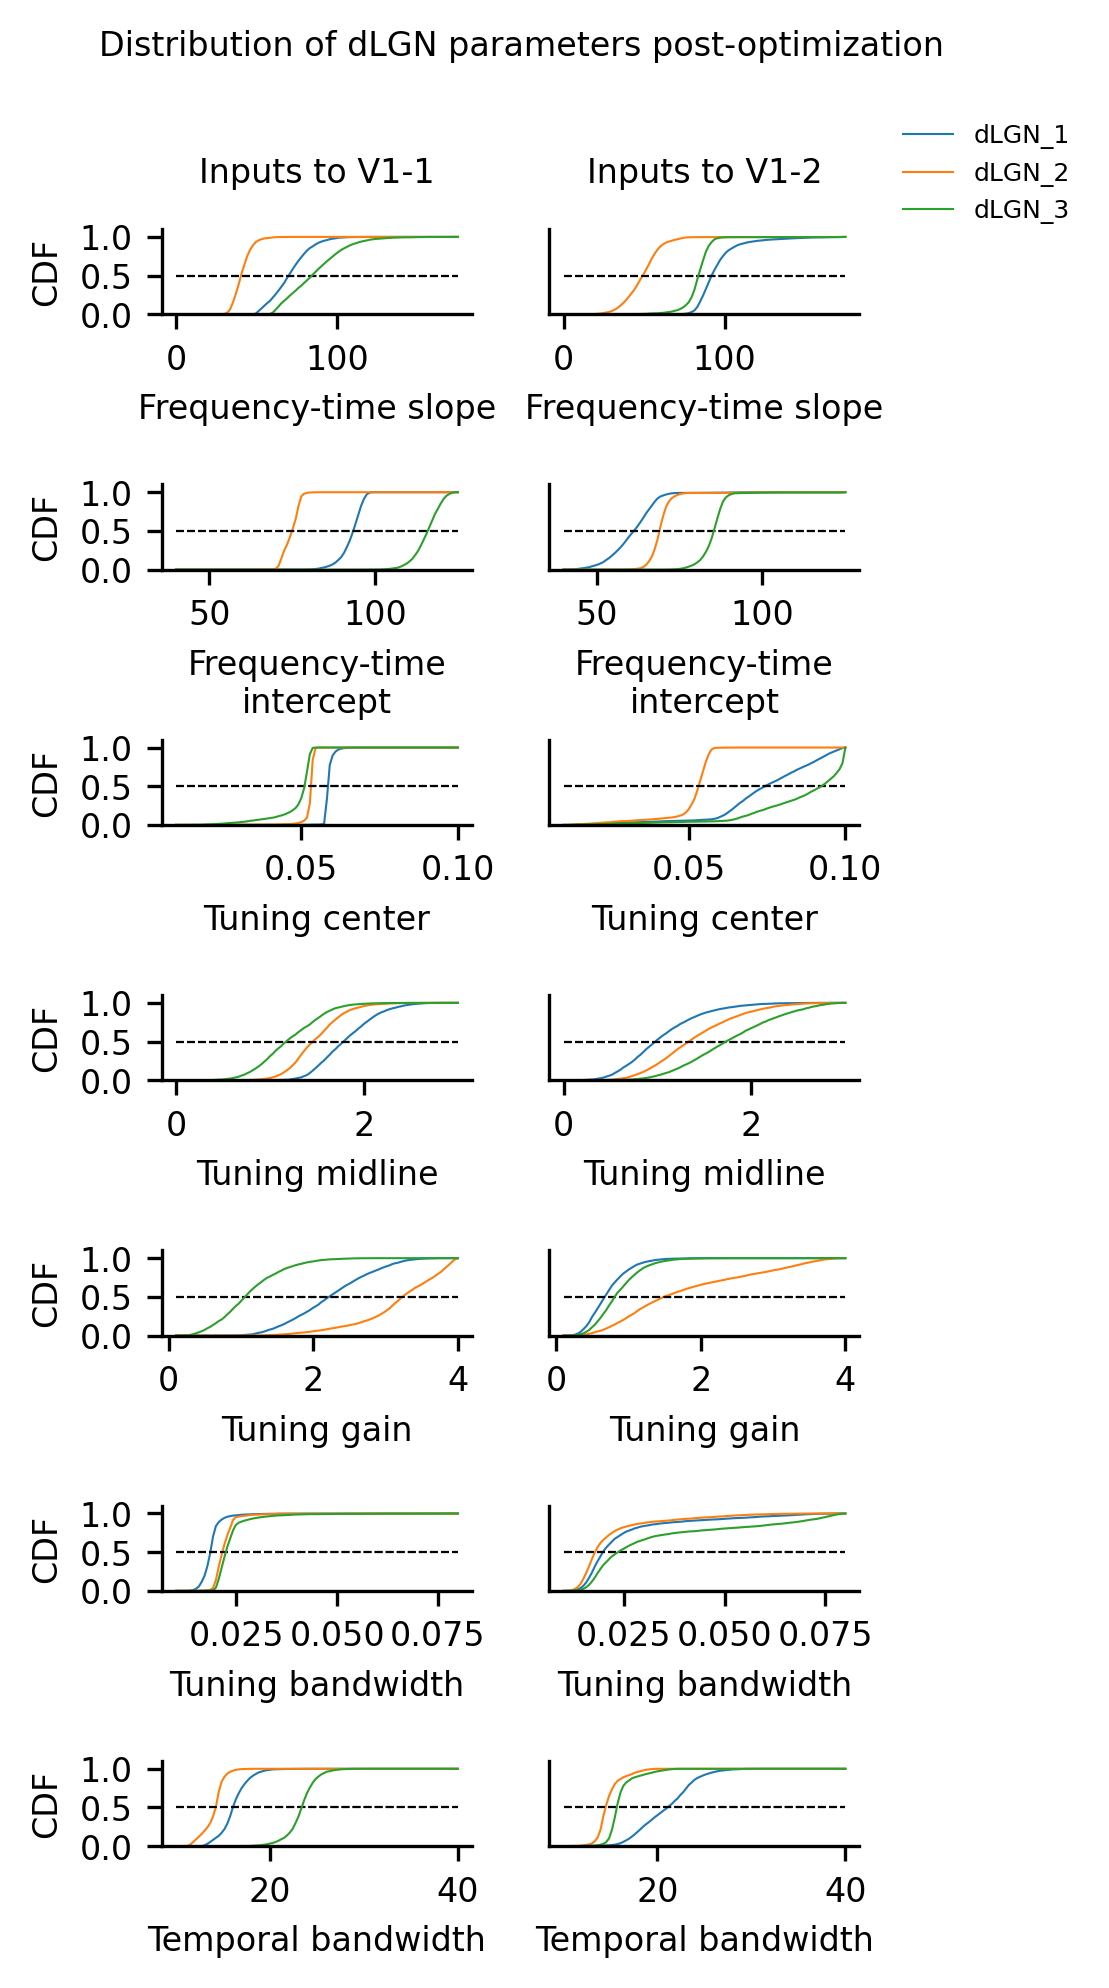

In [43]:
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            d = data['final_opt']['param_history']['dLGN_params'][:,-1][:,u,i,row,0,0]
            x = np.linspace(
                list(param_bounds.values())[:7][row][0],
                list(param_bounds.values())[:7][row][1], 
                100
            )
            kde = ecdf(d).cdf
            y = kde.evaluate(x)

            ymax.append(y.max())

            ax[row, u].plot(x, np.full(len(x), 0.5), '--', color = 'black', linewidth = linewidth)
            ax[row, u].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)

figname = '2d_model_dlgn_param_density_func_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [44]:
lsi_final = np.argsort(data['final_opt']['loss_decay'][-1]) # loss sorting index
final_opt = [
    calculate_monotonicity(data['final_opt']['param_history']['dLGN_params'][:,-1], lsi_final, 0, split=False),
    calculate_monotonicity(data['final_opt']['param_history']['dLGN_params'][:,-1], lsi_final, 1, split=False)
]

In [45]:
# dist1 = []
# A = final_opt[0].mean(0)
# for i in range(1000):
#     S = multi_sample_run[0][np.random.randint(0,4000,120)].mean(0)
#     dist1.append(np.linalg.norm(S - A, ord='fro') / np.linalg.norm(S+A, 'fro'))

In [46]:
100,120

(100, 120)

In [47]:
np.array(multi_sample_run).reshape(2,120,100,7,7).mean(2)

array([[[[ 1.        ,  0.825     ,  0.465     , ..., -0.54      ,
          -0.565     ,  0.815     ],
         [ 0.825     ,  1.        ,  0.36      , ..., -0.735     ,
          -0.765     ,  0.99      ],
         [ 0.465     ,  0.36      ,  1.        , ..., -0.03      ,
          -0.31      ,  0.34      ],
         ...,
         [-0.54      , -0.735     , -0.03      , ...,  1.        ,
           0.505     , -0.715     ],
         [-0.565     , -0.765     , -0.31      , ...,  0.505     ,
           1.        , -0.765     ],
         [ 0.815     ,  0.99      ,  0.34      , ..., -0.715     ,
          -0.765     ,  1.        ]],

        [[ 1.        ,  0.815     ,  0.46      , ..., -0.56      ,
          -0.565     ,  0.8       ],
         [ 0.815     ,  1.        ,  0.3       , ..., -0.775     ,
          -0.745     ,  0.985     ],
         [ 0.46      ,  0.3       ,  1.        , ..., -0.02      ,
          -0.325     ,  0.275     ],
         ...,
         [-0.56      , -0.775     

In [48]:
Pcov_ind = np.array(multi_sample_run).reshape(2,100,120,7,7).mean(1)[0]
Pcov_mean = Pcov_ind.mean(0)
P_best = final_opt[0].mean(0)

<Axes: >

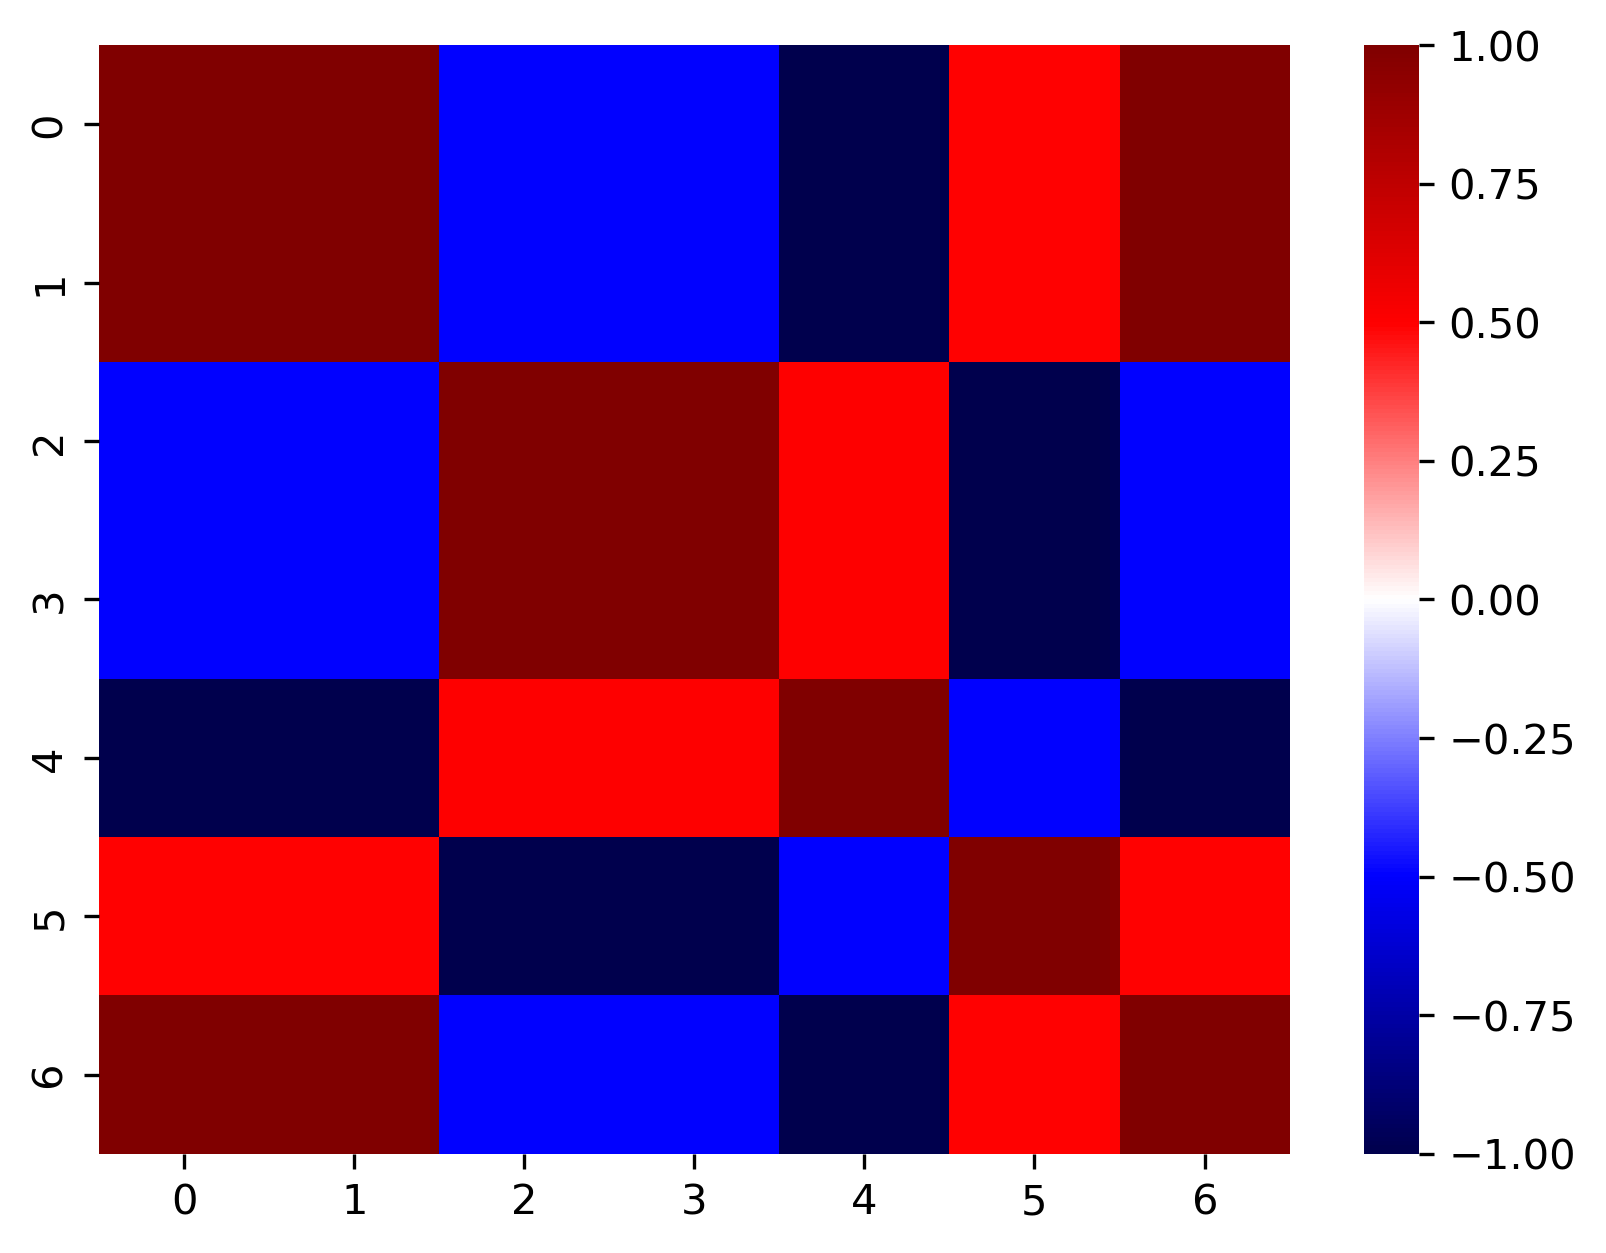

In [49]:
sns.heatmap(P_best, vmin = -1, vmax = 1, cmap = 'seismic')

In [50]:
a = [1,2,3]
b = [3,1,2]
from scipy.stats import spearmanr
spearmanr(a,b)

SignificanceResult(statistic=-0.5, pvalue=0.6666666666666667)

In [51]:
nb = 1000

comp = np.zeros(nb)
for i in range(nb):
    ri1, ri2 = np.random.randint(0,120,2)
    ri3 = np.random.randint(0,120)
    base[i] = np.linalg.norm(Pcov_ind[ri1] - Pcov_ind.mean(0), ord='fro')
    comp[i] = np.linalg.norm(P_best - Pcov_ind.mean(0), ord='fro')
    

NameError: name 'base' is not defined

In [ ]:
base = np.zeros(120)
for i in range(120):
    base[i] = np.linalg.norm(Pcov_ind[i] - Pcov_ind.mean(0), ord='fro')
    #comp[i] = np.linalg.norm(P_best - Pcov_ind.mean(0), ord='fro')

<Axes: >

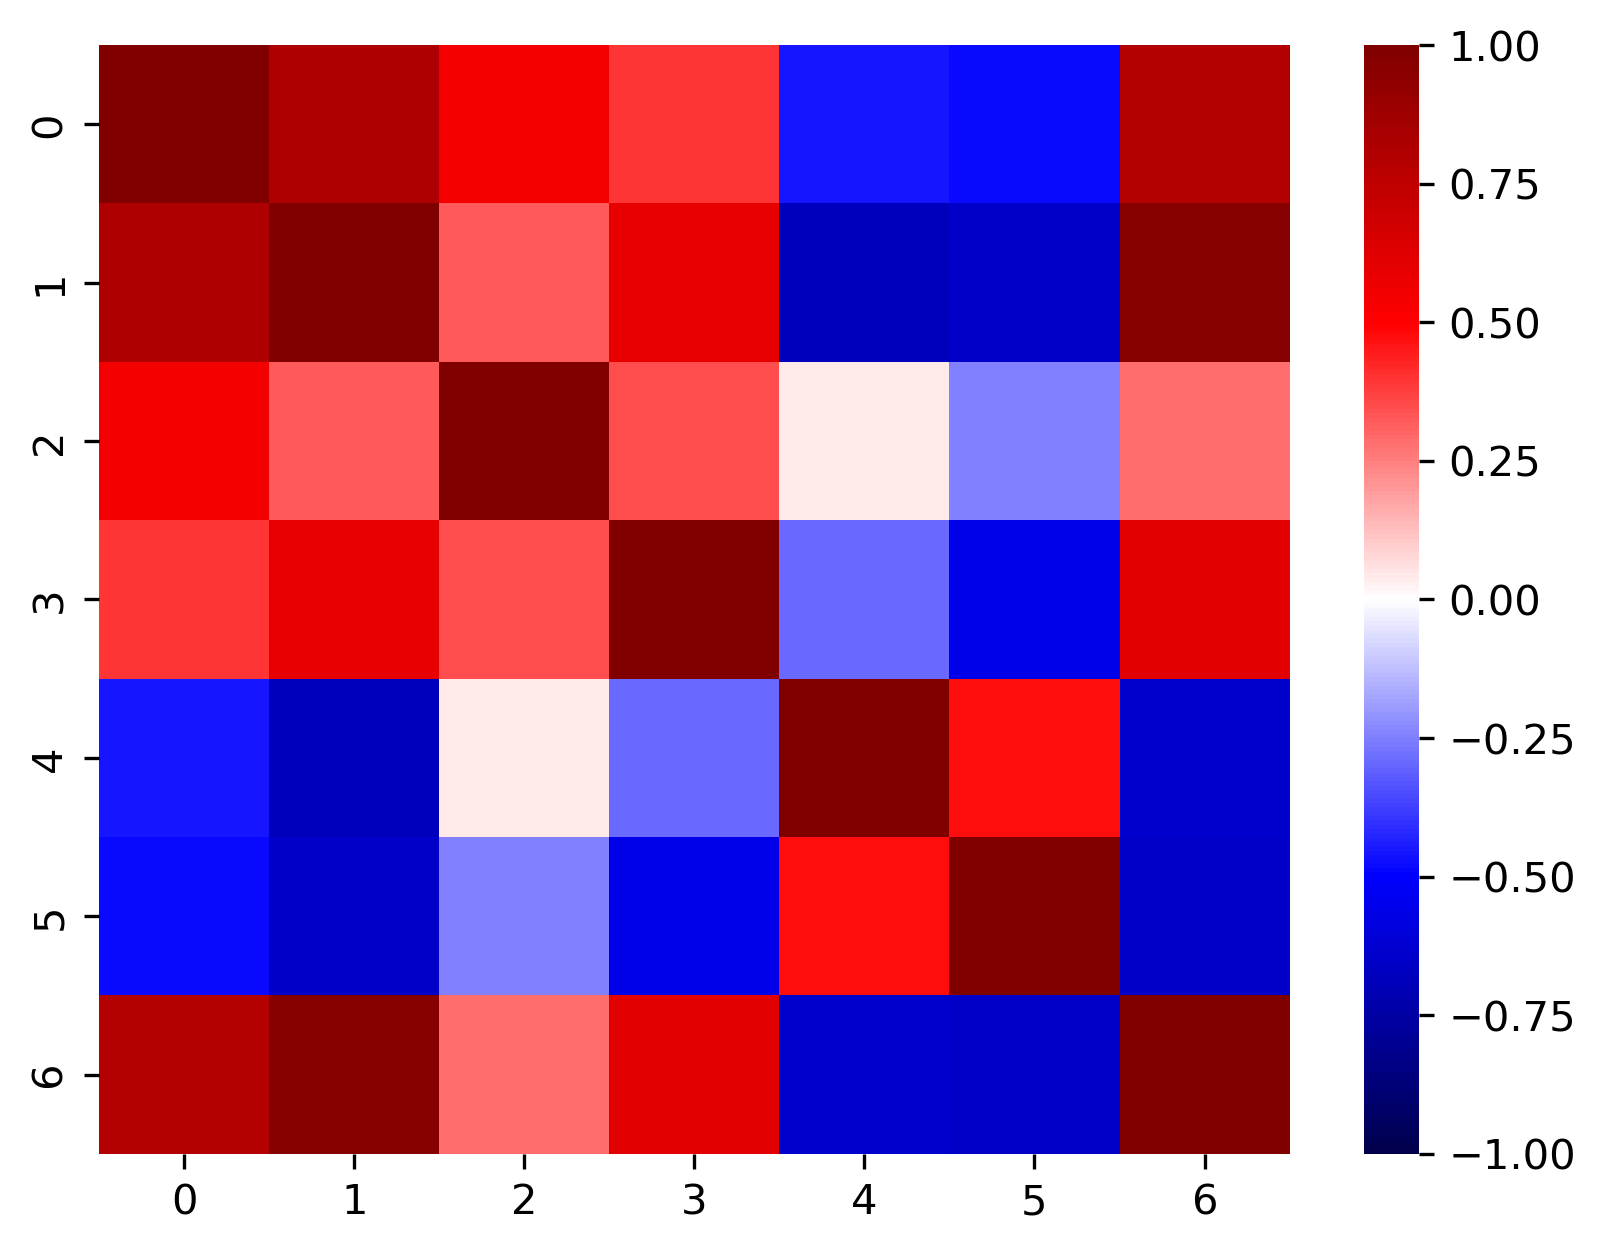

In [ ]:
sns.heatmap(Pcov_ind[0], vmin = -1, vmax = 1, cmap = 'seismic')

(array([ 3., 12., 27., 26., 28., 13.,  5.,  3.,  2.,  1.]),
 array([0.12577537, 0.1764133 , 0.22705122, 0.27768914, 0.32832707,
        0.37896499, 0.42960291, 0.48024084, 0.53087876, 0.58151668,
        0.6321546 ]),
 [<matplotlib.patches.Polygon at 0x1a419ea3b80>])

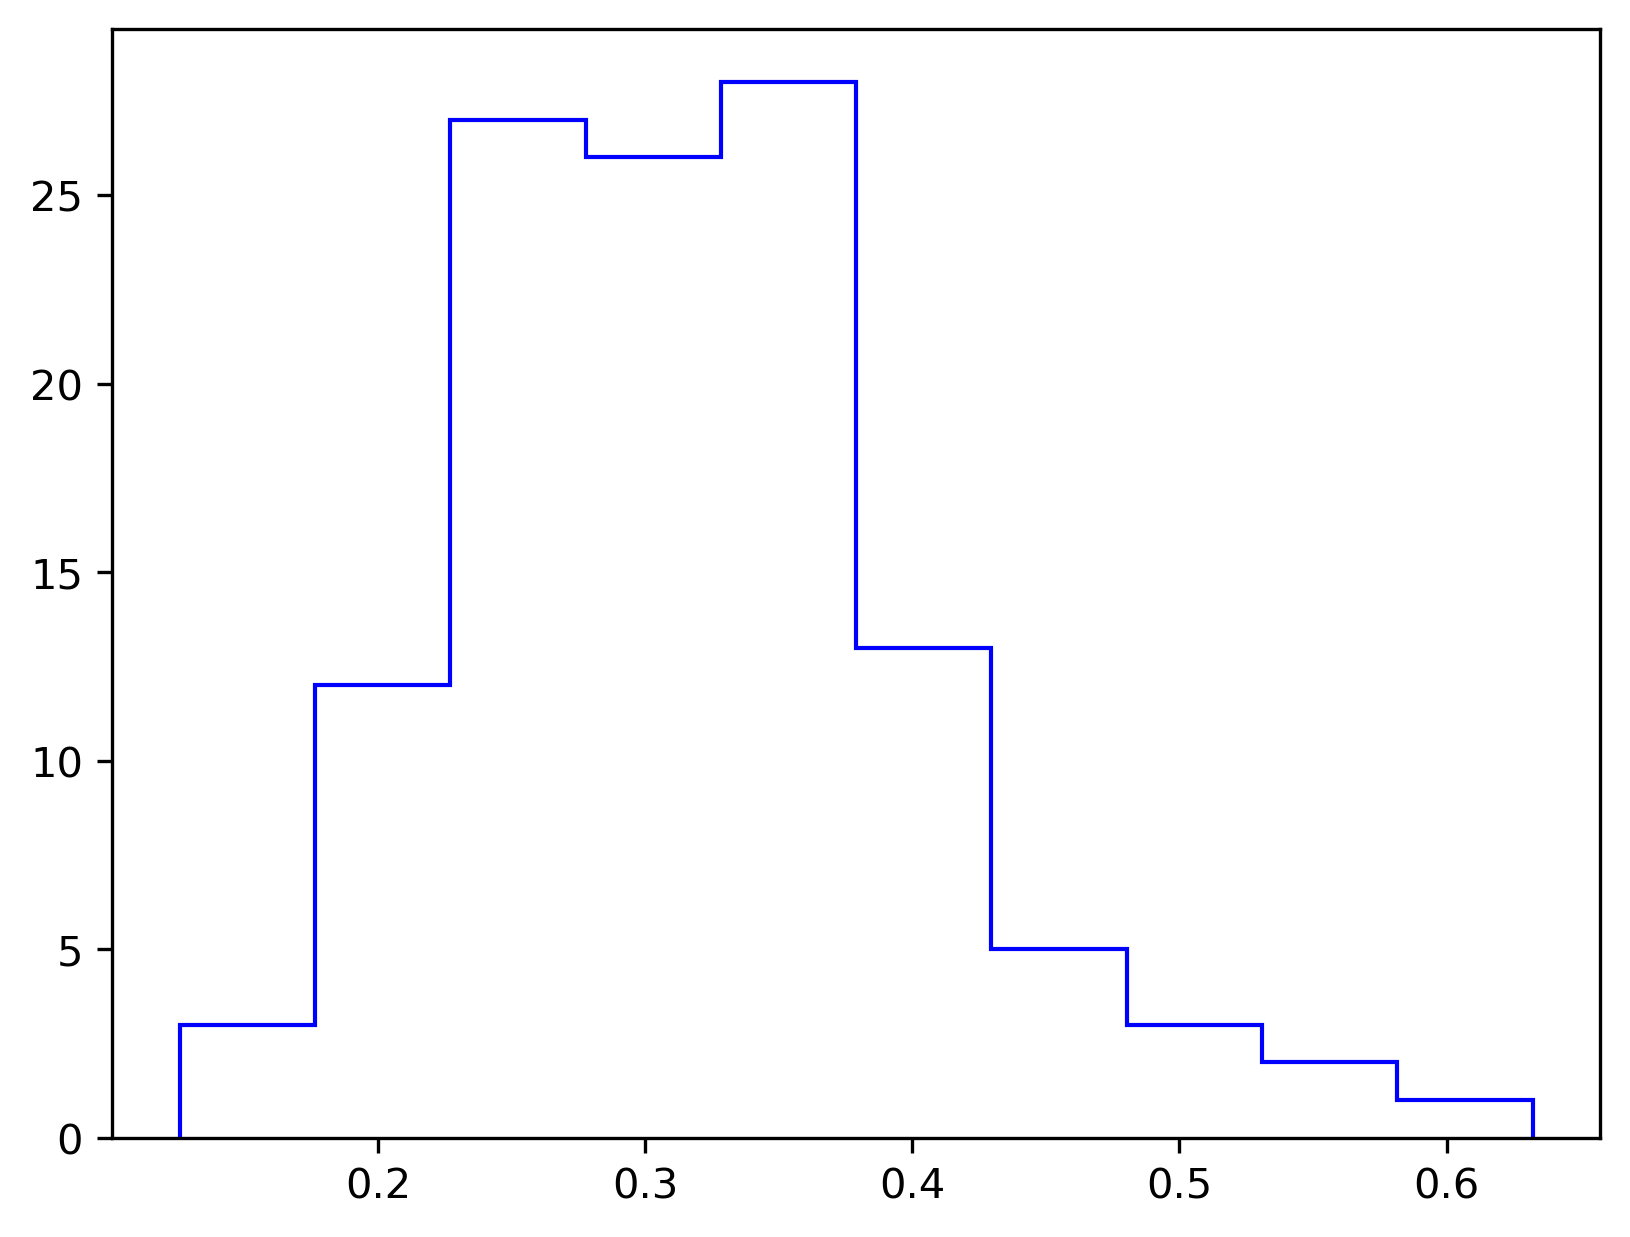

In [ ]:
plt.hist(base, histtype='step', color = 'blue')
#plt.hist(comp, histtype='step', color = 'orange')